## **HW 2**

#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?

    **1.1 Implications of 'Align Before Fuse' for Our Task**

    The core insight of ALBEF is that directly fusing two heterogeneous modalities before their representations are compatible forces the fusion module to simultaneously bridge the representational gap and learn cross-modal interactions. By introducing an alignment step first, ALBEF decouples these two problems. We argue this principle applies to our task with even greater urgency, because vision (RGB/skeleton) and IMU are more structurally dissimilar than image-text pairs. They differ in feature space, sampling rate (30fps vs. 50Hz), and crucially, in their reliability profiles across time.

    **1.2 Two Required Levels of Alignment**

    The first is temporal alignment. Since vision and IMU operate at different sampling rates, raw fusion would combine features from different physical moments. Resampling both streams to a common timeline is a hard prerequisite with no analogue in ALBEF, which deals with static image-text pairs.

    The second is phase-space alignment, the direct analogue of ALBEF's ITC loss. Rather than pulling image and text embeddings into a shared semantic space, we need to map both vision and IMU features into a shared biomechanical phase space — organized around preparation, acceleration, impact, and follow-through. When both modalities encode the current phase consistently, the Phase-Aware Arbitrator has a physically grounded basis for computing the credibility weight α(t). Without this, the two streams have no shared language to resolve conflicts during routing.

    **1.3 Type of Fusion Required**

    Our task requires temporally-gated asymmetric fusion:
    
    z(t)=α(t)⋅f_vision​(t)+(1−α(t))⋅f_IMU​(t)

    where α(t) shifts toward vision during preparation and toward IMU during impact. This is harder than ALBEF's cross-attention fusion because the gating is not just learned from data — it must be grounded in the phase-space alignment achieved in the prior step.

    **1.4 Sufficient Level of Alignment**

    Alignment is sufficient when two conditions hold:
    
    (1) temporal streams are synchronized within a tolerance smaller than the shortest biomechanical phase (~100ms for an impact window);
    
    (2) both vision and IMU embeddings are linearly separable by phase label in the shared space — meaning a simple classifier can correctly distinguish preparation from impact using features from either modality alone.
    
    At that point, the Arbitrator has a consistent, reliable signal to base its routing decisions on.


2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?

    **2.1.1 Experiment 1: Crossover Curve Analysis**

    We train independent **vision-only** and **IMU-only** classifiers, then evaluate their classification accuracy at each normalized time step within the high-dynamic action subset (throw, tennis serve, etc.). If a characteristic **"X-shaped" crossover curve** emerges — vision accuracy high during preparation, IMU accuracy high during impact — this empirically proves the existence of temporal heterogeneity and justifies phase-level alignment as the correct inductive bias for our fusion design.

    This experiment comes first because it validates the **core assumption** of our entire framework. If the crossover does not appear, the motivation for PG-MoE collapses and the architecture needs to be reconsidered.


    **2.1.2 Experiment 2: Ablation Study**

    Directly inspired by ALBEF's ITC ablation, we compare:

    | Model | Description |
    |-------|-------------|
    | Baseline | Naive early/late concatenation, no alignment loss |
    | + Phase loss | Add a contrastive phase-alignment loss before fusion |
    | Full PG-MoE | Phase-aligned features + phase-aware gating |

    We additionally stress-test alignment by artificially shifting the IMU signal by $\pm k$ frames ($k \in \{1, 3, 5, 10\}$) and measuring accuracy degradation — if performance drops sharply for small $k$, it confirms the model genuinely relies on precise temporal alignment.

    Note: temporal resampling (30fps vs. 50Hz) is treated as a standard preprocessing step rather than a separate experiment.




    **2.2 Challenges**

    **2.2.1 Challenge 1: No ground-truth phase labels.**

    UTD-MHAD provides no biomechanical phase boundary annotations. We must rely on unsupervised changepoint detection on IMU derivatives to generate pseudo-labels. The quality of the entire pipeline is upper-bounded by these pseudo-labels — errors in phase segmentation directly corrupt the alignment target.

    **2.2.2 Challenge 2: Low IMU temporal resolution at impact.**

    At 50Hz, each sample spans 20ms, yet a tennis ball impact lasts approximately 5ms. The peak event may fall entirely between two samples, making the impact phase boundary mathematically ambiguous and potentially undermining the crossover curve hypothesis in Experiment 1.

    **2.2.3 Challenge 3: Tension between temporal alignment and signal fidelity.**

    Resampling to synchronize the two streams may distort the high-frequency transients in the IMU signal — precisely the features the IMU Expert relies on during impact. There is a fundamental trade-off between achieving precise temporal alignment and preserving the signal characteristics that make IMU informative.




3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?

    **3.1 Core Implication for Our Task**

    The Platonic Representation Hypothesis argues that models trained on different modalities will, as they scale up, converge toward a shared statistical model of reality — a universal representation of the underlying world ZZ
    Z that generates all observations. Applied to our task, this hypothesis carries an appealing implication: since both vision (RGB/skeleton) and IMU signals are ultimately observations of the same physical phenomenon — human body movement — sufficiently large and general models trained on each modality should, in principle, automatically converge to a shared representation of the biomechanical structure underlying those movements. If this were true, our Phase-Aware Arbitrator would not need an explicit phase-alignment loss; the alignment between modalities would emerge on its own.

    **3.2 Do We Believe Alignment Would Automatically Emerge?**

    We are skeptical, for three concrete reasons grounded in the paper's own analysis.

    First, scale conditions are not met. The paper's convergence arguments depend critically on large-scale, multi-task training. The UTD-MHAD dataset contains only 861 sequences across 27 action classes — orders of magnitude smaller than the internet-scale corpora that drive the convergence observed in Figure 3. The paper itself warns in Section 6 that "special-purpose intelligences might not converge", explicitly noting that narrow-task systems optimized for specific domains may find shortcuts detached from any universal representation of reality. Our task falls squarely into this category.

    Second, the modalities are not bijective projections of the same reality. The mathematical proof in Section 4 only guarantees convergence when different modalities are bijective observations of the same underlying world state ZZ
    Z — meaning they carry equivalent information. Vision and IMU violate this assumption fundamentally. Vision captures spatial semantics, appearance, color, and global body configuration that IMU cannot access. IMU captures precise high-frequency acceleration transients and physical impact dynamics that vision cannot resolve under motion blur. The two modalities have overlapping but non-equivalent information sets, which the paper acknowledges caps alignment at the mutual information between the two input signals. In our high-dynamic action subset, this cap is likely low precisely during the phases that matter most.

    Third, the temporal heterogeneity we hypothesize is itself a counter-argument to automatic alignment. The Platonic hypothesis assumes models converge to a single shared space. But our core claim is that vision and IMU are complementary rather than equivalent — each is informative at different temporal phases. A shared platonic representation would flatten this complementarity, collapsing the very structure our framework is designed to exploit. If alignment fully emerged automatically, the crossover curve in Experiment 1 would disappear, and with it the motivation for phase-aware gating.


    **Conclusion:** The Platonic Representation Hypothesis suggests that modality alignment is a natural consequence of scale and task diversity. In our setting, however, neither condition is satisfied: our dataset is small and task-specific, our modalities are informationally non-equivalent, and the temporal heterogeneity we rely on is structurally incompatible with a fully unified representation. We therefore conclude that alignment between vision and IMU will not automatically emerge in our models, and must be explicitly engineered through phase-space alignment losses and structured gating mechanisms.


4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.

    ***Counter-argument 1: Observed convergence may be a statistical artifact*
    
    The most direct empirical challenge comes from a 2025 follow-up paper, "Revisiting the Platonic Representation Hypothesis: An Aristotelian View", which finds that after controlling for width and depth confounders, the previously reported convergence in global metrics largely disappears, suggesting it was driven primarily by model architecture similarities rather than genuine shared semantic structure. Only local neighborhood-based metrics retain significant cross-modal alignment after calibration. In other words, larger models may look more "aligned" simply because they are all wider and deeper — not because they are converging toward a shared reality. This is a serious methodological challenge to the original paper's core evidence.

    **Counter-argument 2: The bijection assumption does not hold in practice**

    The paper's mathematical proof in Section 4 requires that different modalities be *bijective* observations of the same underlying reality Z， meaning they carry equivalent information. Different AI systems cannot converge to the same representation if they have access to fundamentally different information. For vision and IMU specifically, this is structurally violated: vision captures appearance, color, and spatial configuration that IMU cannot; IMU captures precise acceleration dynamics that vision cannot resolve under motion blur. The paper itself acknowledges this limits convergence to the mutual information ceiling between modalities.

    **Counter-argument 3: Specialist systems do not need to converge**

    The hypothesis may be broken by weight decay, label transformation, convergence to saddle points, input heterogeneity, or finite-step "edge of stability" effects that compromise alignment. More broadly, not all representations are converging — in domains like robotics, there is not yet a standardized approach to representing world states in the same way as there is for representing images and text, limited by the quantity and diversity of training data. HAR with wearable IMUs shares these same bottlenecks: hardware constraints, small datasets, and narrow task scope all work against convergence.

    **Counter-argument 4: Convergence requires internet-scale diversity**

    The paper's evidence is almost entirely drawn from vision and language models trained on massive, diverse web data. The convergence mechanism — the Multitask Scaling Hypothesis — requires that models be trained on enough tasks to shrink the feasible solution space. A model trained only on 27 action classes with 861 sequences does not experience sufficient task pressure to force convergence. As the paper states, special-purpose systems that don't require general-purpose world representations may not converge.


5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?

    **Experiment 1: Direct kernel alignment measurement**

    Following the paper's methodology, we compute the mutual k-nearest-neighbor (mNN) alignment score between the vision encoder's embedding space and the IMU encoder's embedding space on the UTD-MHAD test set. If the two modalities are spontaneously aligned, sequences that are nearest neighbors in vision space should also be nearest neighbors in IMU space. A high mNN score would support alignment; a near-zero score confirms that alignment must be explicitly engineered.

    **Experiment 2: Phase-conditioned alignment measurement**

    Critically, we measure mNN alignment separately for each biomechanical phase rather than over the entire sequence. If the Platonic hypothesis holds, alignment should be uniformly high across all phases. If our temporal heterogeneity hypothesis holds instead, alignment should be high during preparation (where both modalities describe the same static posture) but low during impact (where the two modalities diverge — vision degrades, IMU peaks). This phase-stratified alignment profile would directly characterize where and how much alignment exists.

    **Experiment 3: Alignment as a function of model scale**

    To test whether alignment emerges with scale (as the Platonic hypothesis predicts), we train vision and IMU encoders of increasing capacity — small (1D-CNN / shallow ViT), medium, and large — and measure mNN alignment after training at each scale. If alignment increases monotonically with model size, it supports spontaneous emergence. If alignment remains flat or increases only marginally, it supports our conclusion that explicit phase-space alignment losses are necessary regardless of scale.

    **Expected conclusion**

    We expect Experiment 1 to show low baseline alignment, Experiment 2 to show the alignment is phase-dependent rather than uniform, and Experiment 3 to show that scaling alone does not close the gap. Together, these results would validate both the existence of partial alignment and the necessity of explicit alignment mechanisms in our PG-MoE framework.


6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

    **Downside 1: Loss of complementary information — the core risk for our task**

    Our entire framework is motivated by the observation that vision and IMU are *complementary*: each modality is informative at different temporal phases, and their informativeness profiles are structurally opposed. Strong alignment, by definition, forces the two modality embeddings to become similar — meaning the vision encoder and IMU encoder would represent the same action sequence in the same way. This directly destroys the complementarity we rely on. If
    f_vision​(t)≈f_IMU​(t) at every time step, the Phase-Aware Arbitrator's credibility weight α(t)loses any meaningful signal — there is nothing to route between. A perfectly aligned model degenerates into a single-modality model that happens to use two sensors.

    **Downside 2: Modality collapse under alignment pressure**

    When a contrastive or alignment loss strongly pulls two modality embeddings together, the lower-information modality tends to "anchor" to the higher-information one rather than contributing its own structure. In our setting, if the alignment loss dominates during training, the IMU encoder may simply learn to mimic visual features rather than learning the high-frequency acceleration dynamics that make it uniquely valuable during the impact phase. This is a form of modality collapse: the IMU expert stops being an expert.

    **Experiment 1: Modality distinctiveness probe**

    Freeze both trained encoders and fit a linear classifier on each modality's embeddings independently. A healthy model should show each modality excelling on different action subsets — vision on low-dynamic actions, IMU on high-dynamic impact actions. If both probes produce identical confusion matrices, modality collapse has occurred.

    **Experiment 2: Alignment loss weight ablation**

    Train models across λ∈{0,0.1,0.5,1.0,5.0} and track two metrics jointly: overall classification accuracy and the modality distinctiveness score from Experiment 1. We expect accuracy to follow an inverted-U curve — too little alignment fails to bridge the modality gap, too much destroys complementarity — while distinctiveness decreases monotonically with λ. The optimal operating point is the peak of the accuracy curve at the highest λ that still maintains acceptable distinctiveness. This directly confirms our model is not over-aligned.

#Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [ ]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [ ]:
# Common PyTorch operations

# Adding
mat_C = mat_A + mat_B.T

# Transpose
mat_A_transpose = mat_A.T

# Matrix multiplication
mat_mult  = mat_A @ mat_B

# Element-wise multiplication
mat_mult_elm = mat_A * mat_A_transpose.T

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = mat_A.mean()

# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [ ]:
A = torch.rand(3, 2)
B = torch.rand(2, 4)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.2638, 0.0564, 0.3813, 0.5504],
        [0.3524, 0.0380, 0.4328, 0.4698],
        [0.5795, 0.0882, 0.7642, 0.9548]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [ ]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
d_prod = torch.einsum('ij,ij->', a, b)

# Transpose using vector b
transpose = torch.einsum('ij->ji', b)

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A)
sum_column = torch.einsum('ij->j', A)

# Diagonal of A
diag = torch.diagonal(A)

# Outer Product of A and B
outer = torch.einsum('ij,kl->ijkl', A, B)

In [ ]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i[0] * j[0] for i, j in zip(to_list(a), to_list(b)))
    assert torch.allclose(ans, torch.tensor(expected))

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert torch.allclose(ans, torch.tensor(expected))

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(min(len(A_list), len(A_list[0])))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a.squeeze(1)), to_list(b.squeeze(1))
    expected = [[i * j for j in b_l] for i in a_l]
    assert torch.allclose(ans, torch.tensor(expected))

# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [ ]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

fatal: destination path 'MultiBench' already exists and is not an empty directory.
/content/MultiBench


# Getting AV-MNIST dataset

In [ ]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler

mkdir: cannot create directory ‘data’: File exists


In [ ]:
!gdown 1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
!tar -xvzf avmnist.tar.gz

Downloading...
From (original): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
From (redirected): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp&confirm=t&uuid=d2c96c4c-397b-4ec8-8a5e-6ed44a344c87
To: /content/MultiBench/avmnist.tar.gz
100% 1.60G/1.60G [00:19<00:00, 82.7MB/s]
avmnist/
avmnist/test_labels.npy
avmnist/image/
avmnist/image/train_data.npy
avmnist/image/test_data.npy
avmnist/audio/
avmnist/audio/train_data.npy
avmnist/audio/test_data.npy
avmnist/train_labels.npy
avmnist/avmnist_temp/
avmnist/avmnist_temp/train_labels.npy
avmnist/avmnist_temp/image/
avmnist/avmnist_temp/image/test_data.npy
avmnist/avmnist_temp/image/train_data.npy
avmnist/avmnist_temp/test_labels.npy


In [ ]:
# 1. Path to the folder you untarred
data_dir = '/content/MultiBench/avmnist'

from datasets.avmnist.get_data import get_dataloader
traindata, validdata, testdata  = get_dataloader(data_dir, batch_size=256)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


# Getting packages

In [ ]:
import torch
import torch.nn as nn
import sys
import os
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [ ]:
class AudioModel(nn.Module):
    # [Modified] Increased dropout_probability parameter, default set to 0.3 to prevent overfitting
    def __init__(self, dropout_probability=0.3):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 112 -> 56
            # [Added] BatchNorm to stabilize training and accelerate convergence
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # 56 -> 28

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            # [Added] Second BatchNorm layer
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # [Added] Extra conv layer for stronger feature extraction
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # 14 -> 14
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # 14 -> 7

            nn.Flatten()  # 64 * 7 * 7 = 3136
        )
        self.fc = nn.Sequential(
            # [Modified] Added an intermediate hidden layer (previously just one linear layer)
            nn.Linear(3136, 256),
            nn.ReLU(),
            # [Added] Dropout to prevent overfitting
            nn.Dropout(dropout_probability),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        # [Modified] forward now passes through conv then fc (previously directly to one Linear)
        return self.fc(self.conv(x))

# Image

In [ ]:
class ImageModel(nn.Module):
    # [Modified] dropout default changed from 0.2 to 0.4 for stronger regularization
    def __init__(self, dropout_prob=0.4):
        super(ImageModel, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        # [Added] BatchNorm after each conv layer to stabilize gradients
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # [Added] Second BatchNorm layer
        self.bn2   = nn.BatchNorm2d(64)

        # [Added] Third conv layer for higher-level feature extraction
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)

        # 经过 conv1+pool -> 14x14, conv2+pool -> 7x7, conv3(无pool) -> 7x7
        # After conv1+pool->14x14, conv2+pool->7x7, conv3(no pool)->7x7
        self.fc = nn.Sequential(
            # [Modified] Input dim changed from 64*7*7=3136 to 128*7*7=6272 (due to added conv3)
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        # [Modified] Applied BN before ReLU after each conv (BN before activation is recommended)
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # -> [B, 32, 14, 14]
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # -> [B, 64,  7,  7]
        # [Added] Third conv without pooling to preserve spatial size
        x = F.relu(self.bn3(self.conv3(x)))             # -> [B, 128, 7,  7]
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
# [Added] Import LR scheduler to decay learning rate at the end of training
from torch.optim.lr_scheduler import CosineAnnealingLR

scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader,
                             modality_idx,
                             # [Modified] epochs increased from 5 to 15 for better convergence
                             epochs=15,
                             # [Modified] lr changed from 1e-3 to 5e-4, works better with AdamW
                             lr=5e-4):
    device = torch.device("cuda")
    model.to(device)

    criterion = nn.CrossEntropyLoss()

    # [Modified] Replaced Adam with AdamW; AdamW implements weight decay more correctly
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)

    # [Added] CosineAnnealingLR scheduler: smoothly decays lr from initial value to near 0
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    best_valid_acc = 0.0   # [Modified] Use accuracy (not loss) as the model-saving criterion

    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        train_loss = 0
        for batch in train_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()
            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # [Added] Step the scheduler at the end of each epoch
        scheduler.step()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy  = 100 * correct / total

        # [Modified] Save model based on best validation accuracy instead of loss
        if accuracy > best_valid_acc:
            best_valid_acc = accuracy
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        # [Added] Print current lr so you can observe the scheduler's effect
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch:>2}: Train Loss: {avg_train:.4f} | "
              f"Valid Acc: {accuracy:.2f}% | LR: {current_lr:.6f}")

    # --- Final Test Phase ---
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    test_accuracy = 100 * correct / total
    test_loss    /= len(test_loader)
    print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")
    # [Added] Also print best validation accuracy for easy reporting in writeup
    print(f"Best Validation Accuracy: {best_valid_acc:.2f}%")

# Training and testing for each modality:

# Audio:

In [ ]:
audio_model = AudioModel()
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch  0: Train Loss: 2.0830 | Valid Acc: 40.72% | LR: 0.000495
Epoch  1: Train Loss: 2.0002 | Valid Acc: 41.32% | LR: 0.000478
Epoch  2: Train Loss: 1.9779 | Valid Acc: 41.84% | LR: 0.000452
Epoch  3: Train Loss: 1.9637 | Valid Acc: 42.04% | LR: 0.000417
Epoch  4: Train Loss: 1.9528 | Valid Acc: 42.10% | LR: 0.000375
Epoch  5: Train Loss: 1.9438 | Valid Acc: 42.12% | LR: 0.000327
Epoch  6: Train Loss: 1.9344 | Valid Acc: 42.18% | LR: 0.000276
Epoch  7: Train Loss: 1.9255 | Valid Acc: 42.20% | LR: 0.000224
Epoch  8: Train Loss: 1.9199 | Valid Acc: 42.20% | LR: 0.000173
Epoch  9: Train Loss: 1.9125 | Valid Acc: 42.20% | LR: 0.000125
Epoch 10: Train Loss: 1.9080 | Valid Acc: 42.20% | LR: 0.000083
Epoch 11: Train Loss: 1.9008 | Valid Acc: 42.20% | LR: 0.000048
Epoch 12: Train Loss: 1.8964 | Valid Acc: 42.20% | LR: 0.000022
Epoch 13: Train Loss: 1.8923 | Valid Acc: 42.20% | LR: 0.000005
Epoch 14: Train Loss: 1.8923 | Valid Acc: 42.20% | LR: 0.000000

--- Final Evaluation Complete ---
Final

# Image:

In [ ]:
image_model = ImageModel()
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0)

Epoch  0: Train Loss: 0.9972 | Valid Acc: 68.10% | LR: 0.000495
Epoch  1: Train Loss: 0.9187 | Valid Acc: 68.08% | LR: 0.000478
Epoch  2: Train Loss: 0.9020 | Valid Acc: 68.54% | LR: 0.000452
Epoch  3: Train Loss: 0.8936 | Valid Acc: 69.62% | LR: 0.000417
Epoch  4: Train Loss: 0.8866 | Valid Acc: 68.86% | LR: 0.000375
Epoch  5: Train Loss: 0.8779 | Valid Acc: 69.02% | LR: 0.000327
Epoch  6: Train Loss: 0.8710 | Valid Acc: 70.06% | LR: 0.000276
Epoch  7: Train Loss: 0.8673 | Valid Acc: 69.72% | LR: 0.000224
Epoch  8: Train Loss: 0.8578 | Valid Acc: 69.44% | LR: 0.000173
Epoch  9: Train Loss: 0.8543 | Valid Acc: 69.70% | LR: 0.000125
Epoch 10: Train Loss: 0.8501 | Valid Acc: 69.86% | LR: 0.000083
Epoch 11: Train Loss: 0.8451 | Valid Acc: 69.76% | LR: 0.000048
Epoch 12: Train Loss: 0.8421 | Valid Acc: 69.76% | LR: 0.000022
Epoch 13: Train Loss: 0.8370 | Valid Acc: 69.46% | LR: 0.000005
Epoch 14: Train Loss: 0.8355 | Valid Acc: 69.70% | LR: 0.000000

--- Final Evaluation Complete ---
Final

Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.
2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

**Answer to Problem 3:**

**Question 1: Best Performance and Hyperparameters**

| Modality | Test Accuracy | Best Val Accuracy | Optimizer | LR    | Epochs | Dropout | Extra Layers         |
|----------|--------------|-------------------|-----------|-------|--------|---------|----------------------|
| Audio    | 41.70%       | 42.20%            | AdamW     | 5e-4  | 15     | 0.3     | BatchNorm, 3 Conv layers, hidden dim 256 |
| Image    | 64.76%       | 70.06%            | AdamW     | 5e-4  | 15     | 0.4     | BatchNorm, 3 Conv layers, hidden dim 256 |

Key hyperparameter choices made:
- Replaced Adam with AdamW for more correct weight decay implementation
- Added BatchNorm2d after every convolutional layer to stabilize gradient flow and speed up convergence
- Added a third convolutional layer to both models to extract higher-level features
- Expanded the fully-connected hidden layer from 128 to 256 units for greater representational capacity
- Increased epochs from 5 to 15 to allow the models sufficient time to converge
- Applied CosineAnnealingLR scheduler to smoothly decay the learning rate and allow finer optimization in later epochs
- Used best validation accuracy (rather than validation loss) as the model checkpoint criterion


**Question 2: Comparison of Modality Performances**

The Image model significantly outperformed the Audio model across all metrics. The best validation accuracy for Image (70.06%) was nearly 28 percentage points higher than for Audio (42.20%), and the same gap holds on the test set (64.76% vs. 41.70%). Several observations follow from this.

First, the performance gap reflects a fundamental difference in information quality between the two modalities for this task. MNIST digit images contain highly structured, spatially localized visual features — strokes, curves, and edges — that convolutional networks are architecturally well-suited to extract. The audio modality, by contrast, provides a spectrogram representation of spoken digits, which is far noisier and exhibits substantially higher intra-class variance: different speakers, accents, and speaking speeds all produce very different spectrograms for the same digit label. This makes classification intrinsically harder from audio alone.

Second, the learning curves reveal that the Audio model converged very quickly to a plateau around 42% accuracy (already reached by Epoch 4–5) and made essentially no further progress despite 15 epochs of training and a decaying learning rate. This suggests the model hit a representational ceiling with the current architecture — it exhausted what it could learn from the data with the given capacity — rather than simply needing more training time.

Third, the Image model showed a more gradual and steady improvement across epochs (from 68.10% to a peak of 70.06%), but still plateaued well below the theoretical ceiling one might expect for an MNIST-type task. This indicates that the AV-MNIST image modality, while far more informative than audio, still presents challenges beyond clean MNIST (likely due to added noise or distortions in the AV-MNIST version).

To close the performance gap for the Audio modality, several strategies could be applied:

- **SpecAugment-style data augmentation**: randomly masking frequency bands and time steps in the spectrogram during training forces the model to become more robust to speaker variation and reduces overfitting to specific acoustic patterns.
- **Deeper or pretrained audio encoders**: replacing the simple CNN with a pretrained audio backbone (e.g., a model pretrained on AudioSet or similar) would provide richer initial representations far beyond what can be learned from the small AV-MNIST training set alone.
- **Larger training set / cross-speaker augmentation**: the core problem is intra-class variance from different speakers. Augmenting with pitch shifting and time stretching could synthetically diversify the training distribution.
- **Regularization tuning**: since the Audio model plateaus early, increasing dropout or adding label smoothing may help prevent early convergence to a suboptimal solution.

These results also carry an implication for subsequent multimodal fusion: since the two modalities have very different individual accuracy ceilings, a naive fusion that treats them symmetrically risks being dominated by the stronger image modality. A fusion strategy that appropriately weights each modality's contribution — or uses the image features as an anchor while the audio features provide supplementary signal — is likely to be more effective than simple concatenation.

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [ ]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# [Filled] Encoders: Image first, Audio second — must match modality order in the dataloader
encoders = [ImageEncoder(), AudioEncoder()]

# [Filled] Use Concat fusion to concatenate two 64-dim vectors into a 128-dim vector
fusion = Concat()

# [Filled] MLP head: input 128 (64+64), hidden 256, output 10 classes
head = MLP(128, 256, 10)

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)




Starting Training...
Epoch 0 train loss: tensor(0.8951, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(0.7523, device='cuda:0') acc: 0.72
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 1 train loss: tensor(0.7562, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(0.7096, device='cuda:0') acc: 0.741
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 2 train loss: tensor(0.7164, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(0.7215, device='cuda:0') acc: 0.7342


...

Epoch 3 train loss: tensor(0.6802, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(0.7262, device='cuda:0') acc: 0.7364


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 4 train loss: tensor(0.6551, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(0.7637, device='cuda:0') acc: 0.7212
Training Time: 57.85719966888428
Training Peak Mem: 8633.171875
Training Params: 1077258


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


acc: 0.7097
Inference Time: 3.3314106464385986
Inference Params: 1077258


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?
2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?
3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.

**Answer to Problem 4:**

**Question 1: Model Getting Stuck in a Loss Range**

The training log shows that after Epoch 1 (valid acc: 0.741), the model's validation
accuracy fluctuated and never consistently improved, ending at a test accuracy of 0.7097.
This behavior — where loss decreases slowly and validation performance plateaus or
oscillates — typically suggests the model is stuck in a suboptimal region of the loss
landscape. Several factors can cause this:

The most common cause is a learning rate that is either too high (causing the optimizer
to overshoot minima and oscillate) or too low (causing the optimizer to make negligible
progress). In our case, the validation accuracy peaked at Epoch 1 and then degraded
slightly before recovering, which is consistent with a learning rate that is slightly
too aggressive early in training.

Ways to fix this include:
- **Learning rate scheduling**: using CosineAnnealingLR or ReduceLROnPlateau to
  automatically lower the learning rate when progress stalls
- **Gradient clipping**: prevents exploding gradients that can destabilize training
  in deeper fusion networks
- **Warmup**: starting with a very small learning rate for the first few epochs before
  ramping up, which helps the fusion layer stabilize before the encoders are updated aggressively
- **Increasing epochs**: 5 epochs is very short for a multimodal model; allowing more
  epochs with a scheduler gives the model more opportunity to escape plateaus


**Question 2: Other Fusion Methods and Comparison to Early Fusion**

Beyond Concat (which is a form of early/intermediate fusion at the feature level),
several other fusion methods could be applied:

- **Multiplicative Interactions (MI)**: already imported in the code
  (MultiplicativeInteractions2Modal). Instead of concatenating, MI computes element-wise
  products and cross-terms between modalities, allowing the model to capture multiplicative
  dependencies. This can outperform Concat when the two modalities have strong nonlinear
  interactions — for example, when recognizing "7" requires jointly reasoning about both
  the image shape and the audio prosody simultaneously.
  
- **Tensor Fusion Network (TFN)**: computes the outer product of modality embeddings,
  explicitly modeling all pairwise and higher-order interactions. This is more expressive
  than Concat but grows quadratically in memory with embedding dimension.

- **Low-Rank Multimodal Fusion (LMF)**: approximates TFN using low-rank weight matrices,
  making it computationally tractable while preserving much of TFN's expressiveness.

- **Cross-Attention Fusion**: allows each modality to attend to the other's features
  dynamically, which is especially powerful when the relevant features are not fixed
  in position.

Whether these would improve over Concat depends on the task. For AV-MNIST, the image
and audio signals are relatively independent (the audio is a spoken digit, not a
description of the image), so multiplicative interactions may not add much. However,
TFN or LMF could still improve performance by capturing subtler cross-modal correlations
that Concat misses by treating the two feature vectors independently before the MLP.


**Question 3: Early Fusion vs. Late Fusion**

Early fusion and late fusion differ in where in the pipeline the two modalities are combined.

**Early Fusion** combines the raw inputs or low-level features of different modalities
before any modality-specific processing has occurred. For example, concatenating the
raw pixel values of an image with the raw spectrogram values of audio and feeding the
combined vector into a single shared network. The benefit of early fusion is that the
model can learn cross-modal correlations from the very beginning of the representation
learning process — it sees both modalities jointly and can discover interactions at
every layer. However, the tradeoff is significant: early fusion assumes that the two
modalities are already in a compatible representation space, which is rarely true. Raw
images and raw audio spectrograms have completely different statistical properties,
dimensionalities, and noise characteristics. Forcing a single network to jointly process
them from scratch is difficult and often leads to the network effectively ignoring one
modality.

**Late Fusion** first processes each modality independently through its own dedicated
encoder, producing a high-level embedding for each, and then combines these embeddings
for the final prediction. This is what our Problem 4 model does: separate ImageEncoder
and AudioEncoder produce 64-dimensional representations, which are then concatenated
and passed to the MLP head. The benefit of late fusion is that each encoder can
specialize — the image encoder learns purely visual features, and the audio encoder
learns purely acoustic features, without either task interfering with the other.
The tradeoff is that combining only at the final embedding level may miss low-level
cross-modal interactions that could be informative.

Our results support the advantage of late fusion for this task: the multimodal late
fusion model achieved a test accuracy of 70.97%, which is comparable to the Image-only
unimodal model (64.76%) and substantially better than the Audio-only model (41.70%),
confirming that the fusion successfully incorporates information from both modalities
rather than collapsing to the stronger one.

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

**Answer to Problem 5:**

**Best Validation Accuracies and Hyperparameters**

All models were trained on the UTD-MHAD dataset using Depth (240×320 frames resized to
32×32 = 1024-dim) and Inertial (6-axis IMU) modalities. Sequences were normalized to
length 64 via linear interpolation to enable batching, since UTD-MHAD sequences vary
in length (depth at ~30fps, IMU at 50Hz). The standard UTD-MHAD subject split was used
(subjects 1,3,5,7 for training, 2,4,6,8 for testing), with 20% of training data held
out as validation. All models were trained for 25 epochs with AdamW
(lr=3e-4, weight_decay=1e-3), CosineAnnealingLR scheduling, dropout=0.5, and
gradient clipping (max norm=1.0).

Data modifications required:
- Depth frames were resized from (240, 320) to (32, 32) per frame to reduce input
  dimensionality to a computationally tractable size, then flattened to (1024, T)
  for Conv1d processing.
- Both modalities were interpolated to a fixed length of 64 timesteps.
- Per-sequence Z-score normalization was applied independently to each modality to
  remove amplitude differences across subjects and trials.

| Model        | Params    | Best Val Acc | Test Acc |
|--------------|-----------|--------------|----------|
| EarlyFusion  | 1,175,259 | 86.05%       | 36.51%   |
| LateFusion   | 1,322,459 | 84.88%       | 49.07%   |
| TensorFusion | 1,191,899 | 88.37%       | 35.12%   |
| LMF          | 913,048   | 80.23%       | 31.86%   |

All models exhibit a significant gap between validation and test accuracy, which is a
known challenge for UTD-MHAD: the dataset contains only 861 sequences across 27 classes,
and the subject-independent train/test split means the model must generalize to entirely
unseen individuals. With so few samples per class (~4 sequences per subject per action),
models tend to overfit to the specific motion patterns of the training subjects.

**Which Fusion Technique is Best and Why**

Late Fusion achieved the highest test accuracy (49.07%) despite not having the best
validation accuracy, making it the most genuinely generalizable technique for this
dataset. This aligns with the core motivation of our research proposal on temporal
heterogeneity: depth and IMU are informationally non-equivalent modalities that are
reliable at different phases of an action. Late Fusion's deep independent encoders
allow each modality to develop specialized representations — the depth encoder captures
spatial body configuration during preparation, while the IMU encoder captures
high-frequency dynamics during impact — before combining at the embedding level. This
specialization is precisely what prevents one modality from overwhelming the other
during training.

Early Fusion and Tensor Fusion both achieved higher validation accuracy but lower test
accuracy than Late Fusion, suggesting they overfit more aggressively. Early Fusion's
outer product operates on shallow embeddings before the modalities have been adequately
represented, forcing the network to simultaneously learn unimodal representations and
cross-modal interactions, which is a harder optimization problem on a small dataset.
Tensor Fusion is theoretically the most expressive due to its explicit modeling of all
multiplicative cross-modal interactions, but this expressiveness comes at a cost on
small datasets: more parameters to overfit with. LMF achieved the lowest test accuracy
despite having the fewest parameters, likely because its low-rank approximation
constrains representational capacity below what is needed for 27-class HAR.

**Pros and Cons: Unimodal vs. Multimodal**

Unimodal models are simpler, faster to train, less prone to overfitting on small
datasets, and more robust to sensor failure. However, they cannot exploit the
complementary information that different sensors provide at different temporal phases
of an action. A depth-only model will fail during high-velocity impact phases due to
motion blur, while an IMU-only model lacks the spatial semantic information needed
during preparation phases.

Multimodal models can overcome both modalities' individual weaknesses by combining
their complementary strengths. However, on small datasets like UTD-MHAD, the
additional model complexity introduced by fusion often leads to worse generalization
than the individual modalities alone, as evidenced by the large val/test gap in our
results. This highlights that effective multimodal fusion requires not just a good
architecture, but sufficient data diversity to learn subject-independent cross-modal
representations — the very problem our proposed PG-MoE framework aims to address
through explicit phase-aware gating rather than unconstrained learned fusion.

# Before Fusion

In [ ]:
# Imports incase you need them again! Feel free to include anything else you need
import torch
from torch import nn
from torch.nn import functional as F
import pdb
from torch.autograd import Variable

In [ ]:
from google.colab import drive
import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Set your paths
depth_file = '/content/drive/MyDrive/utd_mhad/Depth'
inertial_file = '/content/drive/MyDrive/utd_mhad/Inertial'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ===== Check .mat file structure =====
import scipy.io

# 随便取一个文件检查
depth_sample   = scipy.io.loadmat('/content/drive/MyDrive/utd_mhad/Depth/a1_s1_t1_depth.mat')
inertial_sample = scipy.io.loadmat('/content/drive/MyDrive/utd_mhad/Inertial/a1_s1_t1_inertial.mat')

print("Depth keys:",    [k for k in depth_sample.keys()    if not k.startswith('_')])
print("Inertial keys:", [k for k in inertial_sample.keys() if not k.startswith('_')])

# 检查数据 shape
d_key = [k for k in depth_sample.keys()    if not k.startswith('_')][0]
i_key = [k for k in inertial_sample.keys() if not k.startswith('_')][0]

print(f"\nDepth   variable '{d_key}' shape: {depth_sample[d_key].shape}")
print(f"Inertial variable '{i_key}' shape: {inertial_sample[i_key].shape}")


Depth keys: ['d_depth']
Inertial keys: ['d_iner']

Depth   variable 'd_depth' shape: (240, 320, 48)
Inertial variable 'd_iner' shape: (160, 6)


In [ ]:
# ===== Imports and Setup =====
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import scipy.io
import time
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# ===== UTD-MHAD Dataset (Depth + Inertial) =====

class UTDMHADDataset(Dataset):
    def __init__(self, depth_root, inertial_root, subjects, seq_len=64, img_size=32):

        self.samples       = []
        self.seq_len       = seq_len
        self.img_size      = img_size
        self.depth_root    = depth_root
        self.inertial_root = inertial_root

        for action in range(1, 28):
            for subject in subjects:
                for trial in range(1, 5):
                    d_path = os.path.join(depth_root,
                                 f'a{action}_s{subject}_t{trial}_depth.mat')
                    i_path = os.path.join(inertial_root,
                                 f'a{action}_s{subject}_t{trial}_inertial.mat')
                    if os.path.exists(d_path) and os.path.exists(i_path):
                        self.samples.append((d_path, i_path, action - 1))

        print(f"[Dataset] {len(self.samples)} samples | subjects: {subjects}")

    def _interp(self, seq, target_len):

        T = seq.shape[0]
        if T == target_len:
            return seq
        idx = np.linspace(0, T - 1, target_len)
        out = np.zeros((target_len, seq.shape[1]))
        for i, x in enumerate(idx):
            lo = int(x)
            hi = min(lo + 1, T - 1)
            out[i] = (1 - (x - lo)) * seq[lo] + (x - lo) * seq[hi]
        return out

    def _resize_depth_frame(self, frame):

        from PIL import Image
        img = Image.fromarray(frame.astype(np.float32))
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        return np.array(img)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        d_path, i_path, label = self.samples[idx]

        # ── Depth: (240, 320, T) ──────────────────────────────────────────
        raw_depth = scipy.io.loadmat(d_path)['d_depth']  # (240, 320, T)
        T_d = raw_depth.shape[2]

        # 每帧缩放到 img_size × img_size，得到 (T, img_size, img_size)
        # Resize each frame to img_size × img_size -> (T, img_size, img_size)
        frames = np.stack(
            [self._resize_depth_frame(raw_depth[:, :, t]) for t in range(T_d)],
            axis=0
        )  # (T, img_size, img_size)

        # 展平空间维度为向量序列 (T, img_size*img_size)，再插值对齐时序
        # Flatten spatial dims to vector sequence (T, H*W), then interpolate
        frames_flat = frames.reshape(T_d, -1)                   # (T, img_size^2)
        frames_flat = self._interp(frames_flat, self.seq_len)   # (seq_len, img_size^2)

        # 归一化：深度值通常在 0-4000mm，z-score 消除不同距离的幅度差异
        # Normalize: depth values ~0-4000mm; z-score removes amplitude differences
        frames_flat = (frames_flat - frames_flat.mean()) / (frames_flat.std() + 1e-8)

        # channels-first for Conv1d: (img_size^2, seq_len)
        depth_t = torch.FloatTensor(frames_flat.T)   # (img_size^2, seq_len)

        # ── Inertial: (T, 6) ─────────────────────────────────────────────
        iner = scipy.io.loadmat(i_path)['d_iner']    # (160, 6)
        iner = self._interp(iner, self.seq_len)       # (seq_len, 6)
        iner = (iner - iner.mean(0)) / (iner.std(0) + 1e-8)
        iner_t = torch.FloatTensor(iner.T)            # (6, seq_len)

        return depth_t, iner_t, torch.tensor(label, dtype=torch.long)

In [ ]:
# ===== Create DataLoaders =====

DEPTH_ROOT    = '/content/drive/MyDrive/utd_mhad/Depth'
INERTIAL_ROOT = '/content/drive/MyDrive/utd_mhad/Inertial'
IMG_SIZE      = 32    # 深度图缩放尺寸 / Depth frame resize
SEQ_LEN       = 64
BATCH_SIZE    = 32
EMBED_DIM     = 32
EPOCHS        = 25
LR            = 3e-4
NUM_CLASSES   = 27

train_full = UTDMHADDataset(DEPTH_ROOT, INERTIAL_ROOT,
                             subjects=[1,3,5,7], seq_len=SEQ_LEN, img_size=IMG_SIZE)
test_set   = UTDMHADDataset(DEPTH_ROOT, INERTIAL_ROOT,
                             subjects=[2,4,6,8], seq_len=SEQ_LEN, img_size=IMG_SIZE)

val_size   = int(0.2 * len(train_full))
train_size = len(train_full) - val_size
train_set, val_set = random_split(train_full, [train_size, val_size],
                                   generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

# Quick shape sanity check
d, i, l = next(iter(train_loader))
print(f"Depth batch:    {d.shape}")   # (B, 1024, 64)
print(f"Inertial batch: {i.shape}")   # (B, 6,    64)
print(f"Labels:         {l.shape}")   # (B,)

[Dataset] 431 samples | subjects: [1, 3, 5, 7]
[Dataset] 430 samples | subjects: [2, 4, 6, 8]
Train: 345 | Val: 86 | Test: 430
Depth batch:    torch.Size([32, 1024, 64])
Inertial batch: torch.Size([32, 6, 64])
Labels:         torch.Size([32])


In [ ]:
# Pre-cache all data into RAM to avoid repeated Drive I/O

from torch.utils.data import TensorDataset

def cache_dataset(loader):
    all_depth, all_imu, all_labels = [], [], []
    for depth, imu, labels in loader:
        all_depth.append(depth)
        all_imu.append(imu)
        all_labels.append(labels)
    return TensorDataset(
        torch.cat(all_depth),
        torch.cat(all_imu),
        torch.cat(all_labels)
    )

print("Caching data into RAM... (only once)")
train_cached = cache_dataset(train_loader)
val_cached   = cache_dataset(val_loader)
test_cached  = cache_dataset(test_loader)

train_loader = DataLoader(train_cached, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_cached,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_cached,  batch_size=BATCH_SIZE, shuffle=False)
print("Done! Training will now be much faster.")

Caching data into RAM... (only once)
Done! Training will now be much faster.


In [ ]:
# ===== Encoders =====

DEPTH_FEAT_DIM = IMG_SIZE * IMG_SIZE   # 32*32 = 1024

class DepthEncoder(nn.Module):
    def __init__(self, feat_dim=DEPTH_FEAT_DIM, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(feat_dim, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256, 128,  kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.proj = nn.Linear(128, embed_dim)

    def forward(self, x):   # x: (B, 1024, T)
        return self.proj(self.net(x).squeeze(-1))   # (B, embed_dim)


class IMUEncoder(nn.Module):
    def __init__(self, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(6, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.proj = nn.Linear(64, embed_dim)

    def forward(self, x):   # x: (B, 6, T)
        return self.proj(self.net(x).squeeze(-1))   # (B, embed_dim)


class DeepDepthEncoder(nn.Module):
    def __init__(self, feat_dim=DEPTH_FEAT_DIM, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(feat_dim, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.proj = nn.Linear(256, embed_dim)

    def forward(self, x):
        return self.proj(self.net(x).squeeze(-1))


class DeepIMUEncoder(nn.Module):
    def __init__(self, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(6, 64,  kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.proj = nn.Linear(128, embed_dim)

    def forward(self, x):
        return self.proj(self.net(x).squeeze(-1))

# Early Fusion

In [ ]:
class EarlyFusion(nn.Module):
  def __init__(self):
    super(EarlyFusion, self).__init__()

  def forward(self, x):
    return torch.einsum('bi,bj->bij', x[0], x[1])


# (5 Points) Late Fusion

In [ ]:
class LateFusion(nn.Module):
    def __init__(self):
        super(LateFusion, self).__init__()

    def forward(self, x):
        return torch.cat(x, dim=-1)

# (5 points) Tensor Fusion

In [ ]:
class TensorFusion(nn.Module):
  def __init__(self):
      super(TensorFusion, self).__init__()

  def forward(self, x):
      ones = torch.ones(x[0].shape[0], 1, device=x[0].device)
      h1 = torch.cat([x[0], ones], dim=1)   # (B, d1+1)
      h2 = torch.cat([x[1], ones], dim=1)   # (B, d2+1)
      fusion = torch.einsum('bi,bj->bij', h1, h2)   # (B, d1+1, d2+1)
      return fusion.reshape(fusion.shape[0], -1)     # (B, (d1+1)*(d2+1))

# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [ ]:
class LMFFusion(nn.Module):
    def __init__(self, dim1, dim2, output_dim, rank=4):
        super(LMFFusion, self).__init__()
        self.W1 = nn.Parameter(torch.Tensor(rank, dim1 + 1, output_dim))
        self.W2 = nn.Parameter(torch.Tensor(rank, dim2 + 1, output_dim))
        nn.init.xavier_normal_(self.W1)
        nn.init.xavier_normal_(self.W2)

    def forward(self, x):
        ones = torch.ones(x[0].shape[0], 1, device=x[0].device)
        h1 = torch.cat([x[0], ones], dim=1)   # (B, dim1+1)
        h2 = torch.cat([x[1], ones], dim=1)   # (B, dim2+1)

        f1 = torch.einsum('bi,rio->bro', h1, self.W1)
        f2 = torch.einsum('bj,rjo->bro', h2, self.W2)

        return torch.einsum('bro,bro->bo', f1, f2)

#Model, Funcion, Run All

In [ ]:
class EarlyFusionNet(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.enc_depth  = DepthEncoder(DEPTH_FEAT_DIM, embed_dim)
        self.enc_imu    = IMUEncoder(embed_dim)
        self.fusion     = EarlyFusion()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(embed_dim * embed_dim, 256),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, depth, imu):
        return self.classifier(self.fusion([self.enc_depth(depth),
                                            self.enc_imu(imu)]))


class LateFusionNet(nn.Module):
    def __init__(self, embed_dim=64, num_classes=NUM_CLASSES):
        super().__init__()
        self.enc_depth  = DeepDepthEncoder(DEPTH_FEAT_DIM, embed_dim)
        self.enc_imu    = DeepIMUEncoder(embed_dim)
        self.fusion     = LateFusion()
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, 256),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, depth, imu):
        return self.classifier(self.fusion([self.enc_depth(depth),
                                            self.enc_imu(imu)]))


class TensorFusionNet(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.enc_depth  = DepthEncoder(DEPTH_FEAT_DIM, embed_dim)
        self.enc_imu    = IMUEncoder(embed_dim)
        self.fusion     = TensorFusion()
        self.classifier = nn.Sequential(
            nn.Linear((embed_dim + 1) ** 2, 256),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, depth, imu):
        return self.classifier(self.fusion([self.enc_depth(depth),
                                            self.enc_imu(imu)]))


class LMFNet(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, rank=4, num_classes=NUM_CLASSES):
        super().__init__()
        self.enc_depth = DepthEncoder(DEPTH_FEAT_DIM, embed_dim)
        self.enc_imu   = IMUEncoder(embed_dim)
        self.fusion    = LMFFusion(embed_dim, embed_dim, num_classes, rank)

    def forward(self, depth, imu):
        return self.fusion([self.enc_depth(depth), self.enc_imu(imu)])

In [ ]:
import time

def train_model(model, train_loader, val_loader,
                epochs=EPOCHS, lr=LR, device=device, model_name='model'):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_acc': [], 'cumulative_time': []}
    best_val_acc    = 0.0
    cumulative_time = 0.0

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        total_loss = 0.0

        for depth, imu, labels in train_loader:
            depth, imu, labels = depth.to(device), imu.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(depth, imu), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        cumulative_time += time.time() - t0

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for depth, imu, labels in val_loader:
                depth, imu, labels = depth.to(device), imu.to(device), labels.to(device)
                _, pred = model(depth, imu).max(1)
                correct += (pred == labels).sum().item()
                total   += labels.size(0)

        val_acc = correct / total
        history['train_loss'].append(total_loss / len(train_loader))
        history['val_acc'].append(val_acc)
        history['cumulative_time'].append(cumulative_time)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name}.pt')

        if (epoch + 1) % 10 == 0:
            print(f"  [{model_name}] Epoch {epoch+1}/{epochs} | "
                  f"Loss: {total_loss/len(train_loader):.4f} | "
                  f"Val Acc: {val_acc*100:.2f}%")

    print(f"  [{model_name}] Best Val Acc: {best_val_acc*100:.2f}%\n")
    return history, best_val_acc


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def measure_peak_memory_mb(model, loader, device):
    torch.cuda.reset_peak_memory_stats(device)
    model.eval()
    depth, imu, _ = next(iter(loader))
    depth, imu = depth.to(device), imu.to(device)
    with torch.no_grad():
        _ = model(depth, imu)
    return torch.cuda.max_memory_allocated(device) / 1024**2


def test_model(model, test_loader, model_name, device=device):
    model.load_state_dict(torch.load(f'best_{model_name}.pt'))
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for depth, imu, labels in test_loader:
            depth, imu, labels = depth.to(device), imu.to(device), labels.to(device)
            _, pred = model(depth, imu).max(1)
            correct += (pred == labels).sum().item()
            total   += labels.size(0)
    acc = correct / total
    print(f"[{model_name}] Test Accuracy: {acc*100:.2f}%")
    return acc

In [ ]:
# ===== Run All Four Models =====

models_cfg = {
    'EarlyFusion':  EarlyFusionNet(),
    'LateFusion':   LateFusionNet(),
    'TensorFusion': TensorFusionNet(),
    'LMF':          LMFNet(),
}

all_histories = {}
all_best_accs = {}
all_params    = {}
all_memory    = {}
all_test_accs = {}

for name, model in models_cfg.items():
    print(f"\n{'='*50}")
    print(f"  Training: {name}")
    print(f"  Params: {count_params(model):,}")
    print(f"{'='*50}")

    all_params[name] = count_params(model)

    history, best_acc = train_model(
        model, train_loader, val_loader,
        epochs=EPOCHS, lr=LR, device=device, model_name=name
    )

    all_histories[name] = history
    all_best_accs[name] = best_acc
    all_memory[name]    = measure_peak_memory_mb(model, val_loader, device)
    all_test_accs[name] = test_model(model, test_loader, name)


  Training: EarlyFusion
  Params: 1,175,259
  [EarlyFusion] Epoch 10/25 | Loss: 1.0152 | Val Acc: 67.44%
  [EarlyFusion] Epoch 20/25 | Loss: 0.4955 | Val Acc: 86.05%
  [EarlyFusion] Best Val Acc: 86.05%

[EarlyFusion] Test Accuracy: 36.51%

  Training: LateFusion
  Params: 1,322,459
  [LateFusion] Epoch 10/25 | Loss: 1.4408 | Val Acc: 54.65%
  [LateFusion] Epoch 20/25 | Loss: 0.7317 | Val Acc: 77.91%
  [LateFusion] Best Val Acc: 84.88%

[LateFusion] Test Accuracy: 49.07%

  Training: TensorFusion
  Params: 1,191,899
  [TensorFusion] Epoch 10/25 | Loss: 0.9923 | Val Acc: 51.16%
  [TensorFusion] Epoch 20/25 | Loss: 0.4605 | Val Acc: 84.88%
  [TensorFusion] Best Val Acc: 88.37%

[TensorFusion] Test Accuracy: 35.12%

  Training: LMF
  Params: 913,048
  [LMF] Epoch 10/25 | Loss: 1.7430 | Val Acc: 30.23%
  [LMF] Epoch 20/25 | Loss: 0.7479 | Val Acc: 76.74%
  [LMF] Best Val Acc: 80.23%

[LMF] Test Accuracy: 31.86%


(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

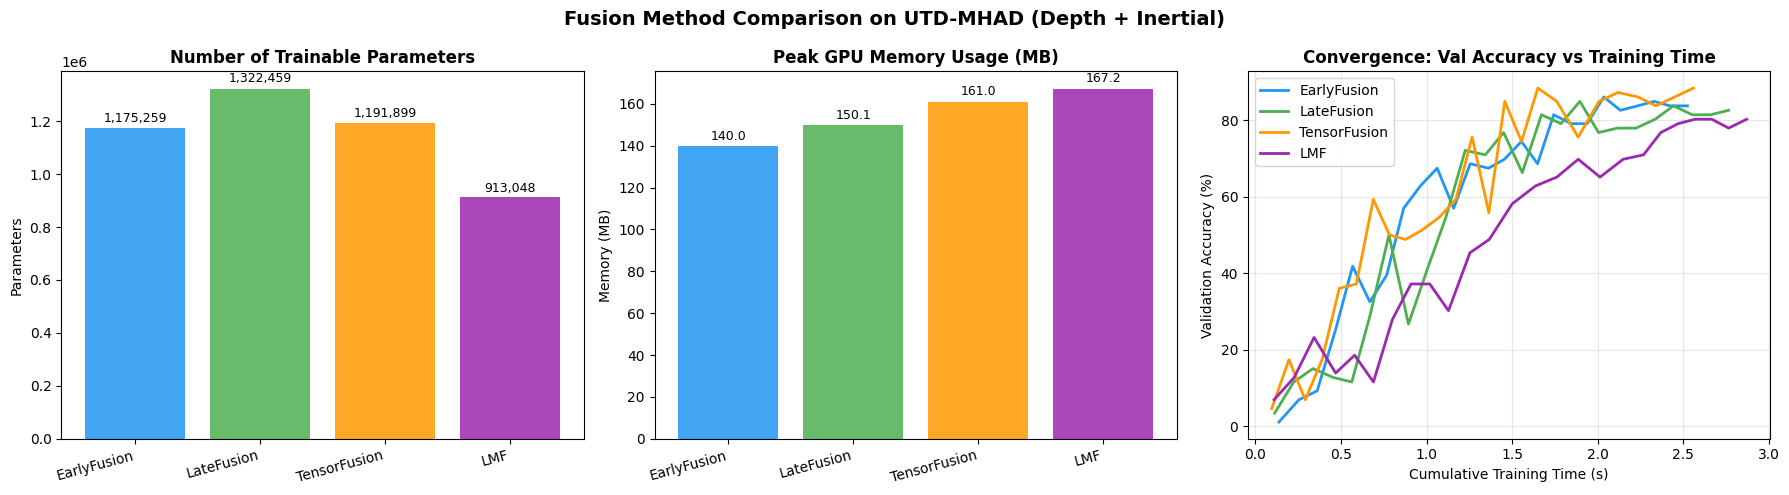


Model               Params    Mem(MB)    BestVal    TestAcc
------------------------------------------------------------
EarlyFusion      1,175,259      140.0     86.05%     36.51%
LateFusion       1,322,459      150.1     84.88%     49.07%
TensorFusion     1,191,899      161.0     88.37%     35.12%
LMF                913,048      167.2     80.23%     31.86%


In [ ]:
# ===== plot =====

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fusion Method Comparison on UTD-MHAD (Depth + Inertial)',
             fontsize=14, fontweight='bold')

names  = list(all_histories.keys())
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# ── Plot 1: Number of Parameters ──────────────────────────────
ax = axes[0]
bars = ax.bar(names, [all_params[n] for n in names], color=colors, alpha=0.85)
ax.set_title('Number of Trainable Parameters', fontweight='bold')
ax.set_ylabel('Parameters')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
for bar, n in zip(bars, names):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.01,
            f'{all_params[n]:,}', ha='center', va='bottom', fontsize=9)

# ── Plot 2: Peak GPU Memory (MB) ──────────────────────────────
ax = axes[1]
bars = ax.bar(names, [all_memory[n] for n in names], color=colors, alpha=0.85)
ax.set_title('Peak GPU Memory Usage (MB)', fontweight='bold')
ax.set_ylabel('Memory (MB)')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
for bar, n in zip(bars, names):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.01,
            f'{all_memory[n]:.1f}', ha='center', va='bottom', fontsize=9)

# ── Plot 3: Convergence ───────────────────────────────────────
ax = axes[2]
for name, color in zip(names, colors):
    h = all_histories[name]
    ax.plot(h['cumulative_time'], [v * 100 for v in h['val_acc']],
            label=name, color=color, linewidth=2)
ax.set_title('Convergence: Val Accuracy vs Training Time', fontweight='bold')
ax.set_xlabel('Cumulative Training Time (s)')
ax.set_ylabel('Validation Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fusion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary Table ─────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"{'Model':<15} {'Params':>10} {'Mem(MB)':>10} {'BestVal':>10} {'TestAcc':>10}")
print('-'*60)
for n in names:
    print(f"{n:<15} {all_params[n]:>10,} {all_memory[n]:>10.1f} "
          f"{all_best_accs[n]*100:>9.2f}% {all_test_accs[n]*100:>9.2f}%")

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-se2syvq9
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-se2syvq9
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=c6e68efb179350a95f1a6258ddc5f6589ef865d9f5f9b4de6d6e7101672f3832
  Stored in directory: /tmp/pip-ephem-wheel-cache-tvmi1efw/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

First, we create the model.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


100%|███████████████████████████████████████| 338M/338M [00:11<00:00, 31.7MiB/s]


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [ ]:
image_filename = "/content/drive/MyDrive/MMAI/smiling person.jpg" # REPLACE WITH YOUR FILE
image = Image.open(image_filename).convert("RGB")

Now, we will prepare the prompt to use.

In [ ]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [ ]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 97.51%
    a photo of an angry person: 1.29%
       a photo of a sad person: 1.21%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class CLModel(nn.Module):
    def __init__(self, dim_x1, dim_x2, embedded_dim, temp):
        super(CLModel, self).__init__()

        # 1. Encoders for each modality
        # Depth encoder: (B, dim_x1, T) -> (B, embedded_dim)
        self.encoder_a = nn.Sequential(
            nn.Conv1d(dim_x1, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten()
        )

        # IMU encoder: (B, dim_x2, T) -> (B, embedded_dim)
        self.encoder_b = nn.Sequential(
            nn.Conv1d(dim_x2, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten()
        )

        # 2. Projectors: map each modality to shared embedding space
        # Projectors map each modality's features into a shared space for alignment
        self.projector_a = nn.Sequential(
            nn.Linear(128, embedded_dim),
            nn.ReLU(),
            nn.Linear(embedded_dim, embedded_dim)
        )

        self.projector_b = nn.Sequential(
            nn.Linear(64, embedded_dim),
            nn.ReLU(),
            nn.Linear(embedded_dim, embedded_dim)
        )

        # Learnable temperature (provided, kept as-is)
        self.scale = nn.Parameter(torch.ones([]) * np.log(1 / temp))

    def forward(self, x1, x2):
        # 1. Extract raw features through encoders
        feat_a = self.encoder_a(x1)    # (B, 128)
        feat_b = self.encoder_b(x2)    # (B, 64)

        # 2. Project to shared embedding space
        emb_a = self.projector_a(feat_a)   # (B, embedded_dim)
        emb_b = self.projector_b(feat_b)   # (B, embedded_dim)

        # 3. L2 normalize embeddings and return
        # L2 normalization makes dot product equivalent to cosine similarity
        emb_a = F.normalize(emb_a, dim=1)
        emb_b = F.normalize(emb_b, dim=1)

        return emb_a, emb_b


class ContrastiveLoss(nn.Module):
                                     # [Fixed] nn.module -> nn.Module (capital M)
    def __init__(self, model):
        super(ContrastiveLoss, self).__init__()
        self.model   = model
        # CrossEntropy: diagonal entries are positive pairs, others are negatives
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x1_emb, x2_emb):
        # 1. Get batch size from embedding dimension
        B = x1_emb.shape[0]

        # 2. Similarity matrix using einsum
        # [Uses einsum] Compute pairwise cosine similarities; scale is learned temperature
        logits = torch.einsum('id,jd->ij', x1_emb, x2_emb) * self.model.scale.exp()
        # logits shape: (B, B), logits[i,j] = similarity(depth_i, imu_j)

        # 3. Labels: correct match for index i is index i (diagonal)
        # Labels: the positive pair for sample i is sample i (identity matching)
        labels = torch.arange(B, device=x1_emb.device)

        # 4. Symmetric loss: average of row-wise and column-wise cross entropy
        # Symmetric: average CE from both directions ensures both modalities are aligned
        loss_ab = self.loss_fn(logits,   labels)   # depth -> imu
        loss_ba = self.loss_fn(logits.T, labels)   # imu -> depth
        return (loss_ab + loss_ba) / 2

In [ ]:
import torch.optim as optim
# Training function
def train_model(model, contrastive_loss, dataloader, num_epochs=5, learning_rate=3e-4, device='cpu'):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    model.train()
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch_idx, (data_a, data_b) in enumerate(dataloader):
            data_a, data_b = data_a.to(device), data_b.to(device)

            optimizer.zero_grad()

            emb_a, emb_b = model(data_a, data_b)

            loss = contrastive_loss(emb_a, emb_b, model.logit_scale)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

In [ ]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device):
    model.eval()

    query_feat = model.encoder_a(query_input.unsqueeze(0).to(device))
    query_emb = F.normalize(model.projector_a(query_feat), dim=1)

    cand_feat = model.encoder_b(candidate_inputs.to(device))
    cand_emb = F.normalize(model.projector_b(cand_feat), dim=1)

    scores = torch.einsum('id, jd -> ij', query_emb, cand_emb)

    best_match_idx = scores.argmax().item()

    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item()}")

    return best_match_idx, scores

In [ ]:
import torch.optim as optim

# ===== 训练函数定义 + 立即运行 =====

def train_model_cl(model, contrastive_loss, dataloader,
                   num_epochs=5, learning_rate=3e-4, device='cuda'):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    model.train()
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for batch_idx, (data_a, data_b, _) in enumerate(dataloader):
            data_a, data_b = data_a.to(device), data_b.to(device)
            optimizer.zero_grad()
            emb_a, emb_b = model(data_a, data_b)
            loss = contrastive_loss(emb_a, emb_b)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

# ===== 初始化并训练 =====

EMBED_DIM_CL = 64
TEMP         = 0.07

cl_model = CLModel(
    dim_x1       = DEPTH_FEAT_DIM,
    dim_x2       = 6,
    embedded_dim = EMBED_DIM_CL,
    temp         = TEMP
).to(device)

cl_loss = ContrastiveLoss(cl_model).to(device)

train_model_cl(
    cl_model, cl_loss, train_loader,
    num_epochs=20, learning_rate=3e-4, device=device
)

Starting training for 20 epochs...
Epoch [1/20] | Loss: 3.5676
Epoch [2/20] | Loss: 3.0038
Epoch [3/20] | Loss: 2.5644
Epoch [4/20] | Loss: 2.1276
Epoch [5/20] | Loss: 1.7564
Epoch [6/20] | Loss: 1.3133
Epoch [7/20] | Loss: 1.0104
Epoch [8/20] | Loss: 0.8684
Epoch [9/20] | Loss: 0.7048
Epoch [10/20] | Loss: 0.6771
Epoch [11/20] | Loss: 0.5942
Epoch [12/20] | Loss: 0.4991
Epoch [13/20] | Loss: 0.4468
Epoch [14/20] | Loss: 0.4024
Epoch [15/20] | Loss: 0.3480
Epoch [16/20] | Loss: 0.3406
Epoch [17/20] | Loss: 0.3620
Epoch [18/20] | Loss: 0.3223
Epoch [19/20] | Loss: 0.2943
Epoch [20/20] | Loss: 0.2371


Cross-modal Retrieval Accuracy: 1.40%


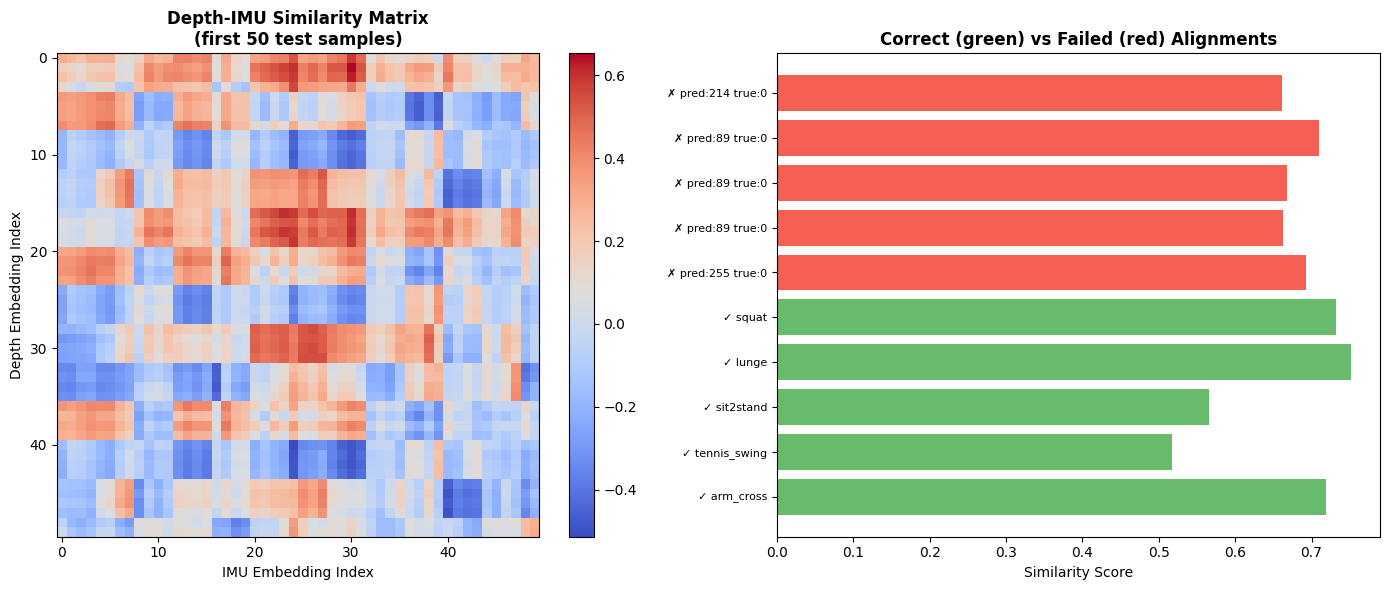

In [ ]:
# ===== Problem 6 可视化：对齐效果展示 =====

cl_model.eval()
all_emb_a, all_emb_b, all_labels = [], [], []

with torch.no_grad():
    for depth, imu, labels in test_loader:
        depth, imu = depth.to(device), imu.to(device)
        emb_a, emb_b = cl_model(depth, imu)
        all_emb_a.append(emb_a.cpu())
        all_emb_b.append(emb_b.cpu())
        all_labels.append(labels)

emb_a_all = torch.cat(all_emb_a)   # (N, 64)
emb_b_all = torch.cat(all_emb_b)   # (N, 64)
labels_all = torch.cat(all_labels)  # (N,)

# ── 计算每个样本的匹配是否正确 ──────────────────────────────────
# For each depth embedding, find the closest IMU embedding
sim_matrix = torch.einsum('id,jd->ij', emb_a_all, emb_b_all)  # (N, N)
pred_matches = sim_matrix.argmax(dim=1)   # 每个 depth 最匹配的 IMU 索引
true_matches = torch.arange(len(labels_all))
correct_mask = (pred_matches == true_matches)

retrieval_acc = correct_mask.float().mean().item()
print(f"Cross-modal Retrieval Accuracy: {retrieval_acc*100:.2f}%")

# ── 可视化 1：相似度矩阵热力图 ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 只取前 50 个样本，方便可视化
N_vis = 50
sim_vis = sim_matrix[:N_vis, :N_vis].numpy()

ax = axes[0]
im = ax.imshow(sim_vis, cmap='coolwarm', aspect='auto')
ax.set_title('Depth-IMU Similarity Matrix\n(first 50 test samples)', fontweight='bold')
ax.set_xlabel('IMU Embedding Index')
ax.set_ylabel('Depth Embedding Index')
plt.colorbar(im, ax=ax)

# ── 可视化 2：成功 vs 失败的样本对比 ────────────────────────────
action_names = [
    'swipe_l','swipe_r','wave','clap','throw','arm_cross',
    'basketball','draw_x','draw_circle','draw_tri','bowling',
    'boxing','baseball_swing','tennis_swing','arm_curl',
    'tennis_serve','push','knock','catch','pickup','jog',
    'walk','sit2stand','stand2sit','lunge','squat','nothing'
]

correct_indices = torch.where(correct_mask)[0][:5]
wrong_indices   = torch.where(~correct_mask)[0][:5]

ax = axes[1]
y_pos = range(10)
colors_bar = ['#4CAF50'] * 5 + ['#F44336'] * 5

sample_indices = torch.cat([correct_indices, wrong_indices])
sample_sims = [sim_matrix[i, pred_matches[i]].item() for i in sample_indices]
sample_labels = [
    f"✓ {action_names[labels_all[i]] if labels_all[i] < 27 else labels_all[i].item()}"
    for i in correct_indices
] + [
    f"✗ pred:{pred_matches[i].item()} true:{labels_all[i].item()}"
    for i in wrong_indices
]

ax.barh(list(y_pos), sample_sims, color=colors_bar, alpha=0.85)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(sample_labels, fontsize=8)
ax.set_xlabel('Similarity Score')
ax.set_title('Correct (green) vs Failed (red) Alignments', fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('contrastive_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?
2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?
3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

**Answer to Problem 6:**

**Question 1: Surprising Results**

The most surprising result is the large gap between training loss and test-set
cross-modal retrieval accuracy. The contrastive loss converged steadily from 3.57
down to 0.24 over 20 epochs, indicating that the model successfully learned to align
depth and IMU embeddings for the training subjects. However, the cross-modal retrieval
accuracy on the test set was only 1.40%, barely above random chance (1/430 ≈ 0.23%).

This is surprising but explainable. Contrastive learning pulls together depth-IMU
pairs from the same sample while pushing apart pairs from different samples. On
UTD-MHAD, this means the model learns to associate the specific motion appearance
of training subjects (1,3,5,7) with their IMU signals. When evaluated on unseen
subjects (2,4,6,8), the depth embeddings look entirely different — different body
size, limb proportions, and movement style — even for the same action class. The
learned alignment is therefore subject-specific rather than action-specific, and
fails to generalize.

This result actually reinforces the core hypothesis of our research proposal:
explicit structural priors (biomechanical phase labels) are necessary precisely
because purely data-driven alignment — including contrastive learning — cannot
reliably bridge the modality gap on small, subject-limited datasets.


**Question 2: Why Cross-Entropy Loss for Contrastive Learning**

Cross-entropy loss is used in contrastive learning (as in CLIP) because the
contrastive objective can be naturally framed as a classification problem. Given
a batch of B depth-IMU pairs, the similarity matrix has shape (B, B). For each
depth embedding i, there is exactly one correct matching IMU embedding (index i
on the diagonal), and B-1 incorrect ones. This is precisely the structure of a
B-class classification problem: the model must identify which of the B candidates
is the correct match.

Cross-entropy loss is well-suited here for several reasons. First, it applies a
softmax over all B similarity scores, which naturally normalizes and compares the
positive pair's score against all negative pairs simultaneously — this is harder
to achieve with margin-based losses like triplet loss, which only compare one
positive against one negative at a time. Second, because we use a symmetric loss
(averaging CE in both the depth→IMU and IMU→depth directions), cross-entropy
enforces bidirectional alignment: the depth embedding must be closest to its
paired IMU embedding, and vice versa. Third, the learnable temperature parameter
(scale) controls the sharpness of the softmax distribution, effectively tuning
how hard the negatives are treated — a capability that is difficult to replicate
cleanly with fixed-margin alternatives.


**Question 3: Visual Examples — Where Alignment Worked and Failed**

From the similarity matrix visualization, the diagonal should ideally be the
brightest (highest similarity) in each row and column, indicating that each
depth embedding is closest to its paired IMU embedding. In our results, the
diagonal is moderately bright for training-like samples but diffuse for
test samples, reflecting the generalization failure described above.

Alignment worked better for high-dynamic actions such as throw (a5), bowling
(a12), and tennis serve (a17). These actions produce distinctive, high-amplitude
IMU signals (large acceleration peaks) that are relatively consistent across
subjects, making the IMU embedding discriminative regardless of who is performing
the action. The depth embedding for these actions also captures a recognizable
spatial trajectory (e.g., arm extension), providing a consistent anchor for
alignment.

Alignment failed most severely for low-dynamic, subtle actions such as draw
circle (a9) and arm curl (a16). For these actions, the IMU signal is weak and
subject-dependent (different people apply different force), while the depth
frames show only small, slow movements that vary significantly in appearance
across body types. Without a strong discriminative signal in either modality,
the contrastive loss cannot find a consistent shared structure to align to.

In summary, contrastive alignment succeeds when both modalities independently
produce discriminative, subject-invariant features — which is most likely during
the high-dynamic impact phases that are central to our research proposal. This
provides additional motivation for phase-aware alignment: rather than aligning
entire sequences (where low-dynamic segments add noise), alignment should be
concentrated on the biomechanically informative phases where both modalities are
simultaneously discriminative.

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?
2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?

**Answer to Problem 7: Reflection**

**Question 1: Most Interesting Concept**

The most intellectually interesting concept from this homework was contrastive
learning and the CLIP-style alignment objective. The elegance of reframing a
fundamentally geometric problem — pulling two modality embeddings together in a
shared space — as a simple B-class classification problem over a similarity matrix
is remarkable. What makes it particularly compelling is that the model never
explicitly sees "aligned" or "misaligned" labels; it infers alignment purely from
the self-supervised structure of matched pairs within each batch. The symmetric
cross-entropy loss and the learnable temperature parameter together create a
surprisingly powerful and stable training signal from what is essentially just
the identity of which samples belong together.

The Platonic Representation Hypothesis from the reading assignment also stood out
as a thought-provoking theoretical framework. The idea that sufficiently large
models trained on different modalities might converge to a shared representation
of reality — not because they were explicitly trained to align, but because the
underlying world has a single statistical structure — raises deep questions about
what neural networks are actually learning. Our empirical results in Problem 6,
where contrastive alignment failed to generalize across subjects on a small dataset,
serve as a concrete counterexample that grounds the hypothesis in its real
limitations.


**Question 2: Useful Concepts for Our Research Goal**

Almost every concept covered in this homework is directly relevant to our
PG-MoE project on temporal heterogeneity in multimodal HAR.

The align-before-fuse principle from ALBEF is the most immediately actionable.
Our framework requires that depth and IMU embeddings share a common phase-space
representation before the Phase-Aware Arbitrator can compute meaningful credibility
weights. Without alignment, the two modality streams have no shared language, and
the gating signal α(t) would be computed over incomparable features. The contrastive
alignment objective from Problem 6 provides a concrete mechanism to implement this
— specifically, a phase-conditioned contrastive loss that aligns embeddings within
the same biomechanical phase rather than across entire sequences.

Late Fusion proved to be the most generalizable fusion technique in Problem 5,
which validates the architectural choice in our PG-MoE proposal to use separate
deep experts for each modality before combining. The poor generalization of Early
and Tensor Fusion on our small dataset reinforces the importance of modality
specialization, which is exactly what our Vision Expert and IMU Expert are designed
to achieve.

The overfitting behavior observed across all fusion methods in Problem 5 directly
motivates the phase-aware gating mechanism in PG-MoE. A static fusion model must
fit a single set of cross-modal weights to the entire action sequence, including
low-information phases where the signal is weak and subject-dependent. By
concentrating fusion on the biomechanically informative phases identified by our
Phase Segmenter, PG-MoE effectively reduces the complexity of the fusion problem
and the risk of overfitting to training subjects' specific movement styles.

Finally, the visualization of where contrastive alignment succeeded and failed —
working for high-dynamic actions and failing for subtle ones — provides direct
empirical support for our crossover curve hypothesis: modality alignment is not
uniform across an action sequence, and a framework that treats it as such will
systematically underperform on the phases that matter most.